In [2]:
import numpy as np
import xarray as xr
import yaml
import pandas as pd
import matplotlib.pyplot as plt

{'timestamp': '20211029T140100Z', 'ids': [78], 'description': ['frame rate issues', 'blurring', 'rectification problems', 'exposure issues'], 'quality': 'bad'}
{'timestamp': '20211029T143100Z', 'ids': [78], 'description': ['frame rate issues', 'rectification problems', 'blurring', 'droplets', 'exposure issues'], 'quality': 'bad'}
{'timestamp': '20211013T130100Z', 'ids': [29], 'description': ['droplets', 'good wave contrast', 'frame rate issues', 'exposure issues'], 'quality': 'medium'}
{'timestamp': '20211028T153100Z', 'ids': [68], 'description': ['frame rate issues', 'rectification problems', 'exposure issues'], 'quality': 'medium'}
{'timestamp': '20211026T133100Z', 'ids': [58], 'description': ['clear waves', 'frame rate issues', 'good rectification', 'boat present'], 'quality': 'good'}
{'timestamp': '20211008T170100Z', 'ids': [18], 'description': ['missing cameras', 'exposure issues', 'artifacts', 'whitecapping'], 'quality': 'bad'}
{'timestamp': '20211026T160100Z', 'ids': [59], 'desc

(18904.625694444443, 18929.563194444443)

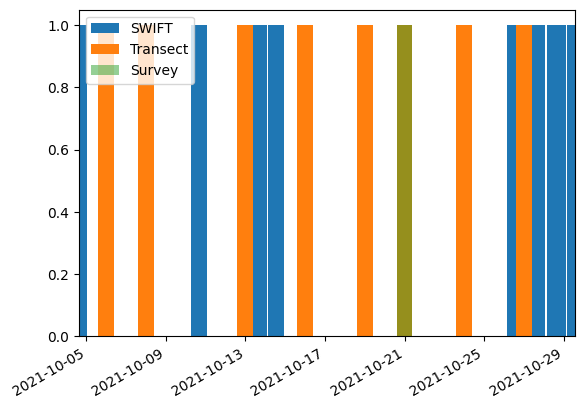

In [157]:
video_metadata = yaml.safe_load(open('../data/argus/metadata/video_metadata.yaml'))

missions_with_video_data = set()
times = {}

for video in video_metadata:
    print(video)
    if video['quality'] != 'bad':
        for mission_id in video['ids']:
            times[mission_id] = pd.to_datetime(video['timestamp'])
            missions_with_video_data.add(mission_id)

print('Missions with data', missions_with_video_data)

times = np.array([*times.values()])
print('Date Range')
print(times.min())
print(times.max())

from glob import glob
survey_times = []
for file in glob('../data/bathy/*surveyDEM*.nc'):
    # print(file.split('_')[-1].split('.')[0])
    survey_times.append(
        pd.to_datetime(file.split('_')[-1].split('.')[0])
    )
transect_times = []
for file in glob('../data/bathy/*elevationTransect*.nc'):
    print(file.split('_')[-1].split('.')[0])
    transect_times.append(
        pd.to_datetime(file.split('_')[-1].split('.')[0])
    )

fig = plt.figure()
plt.bar(times, np.ones_like(times), label='SWIFT')
plt.bar(transect_times, np.ones_like(transect_times), label='Transect')
plt.bar(survey_times, np.ones_like(survey_times), label='Survey', alpha=0.5)
plt.legend()
fig.autofmt_xdate()
plt.xlim(times.min(), times.max())

In [147]:
# Load the waves datasets
wave_df = pd.read_csv('thirdparty/DUNEXMainExp/microSWIFT_data/wave_realizations_df.csv')
breaker_df = pd.read_csv('thirdparty/DUNEXMainExp//microSWIFT_data/breaker_df.csv')
# Load bathymetry from 10/21
bathy = xr.load_dataset('../data/bathy/FRF_geomorphology_DEMs_surveyDEM_20211021.nc').isel(time=0)


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_92112/3589657816.py:10: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  return (x - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_92112/3589657816.py:10: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  return (x - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')


<Figure size 2000x500 with 0 Axes>

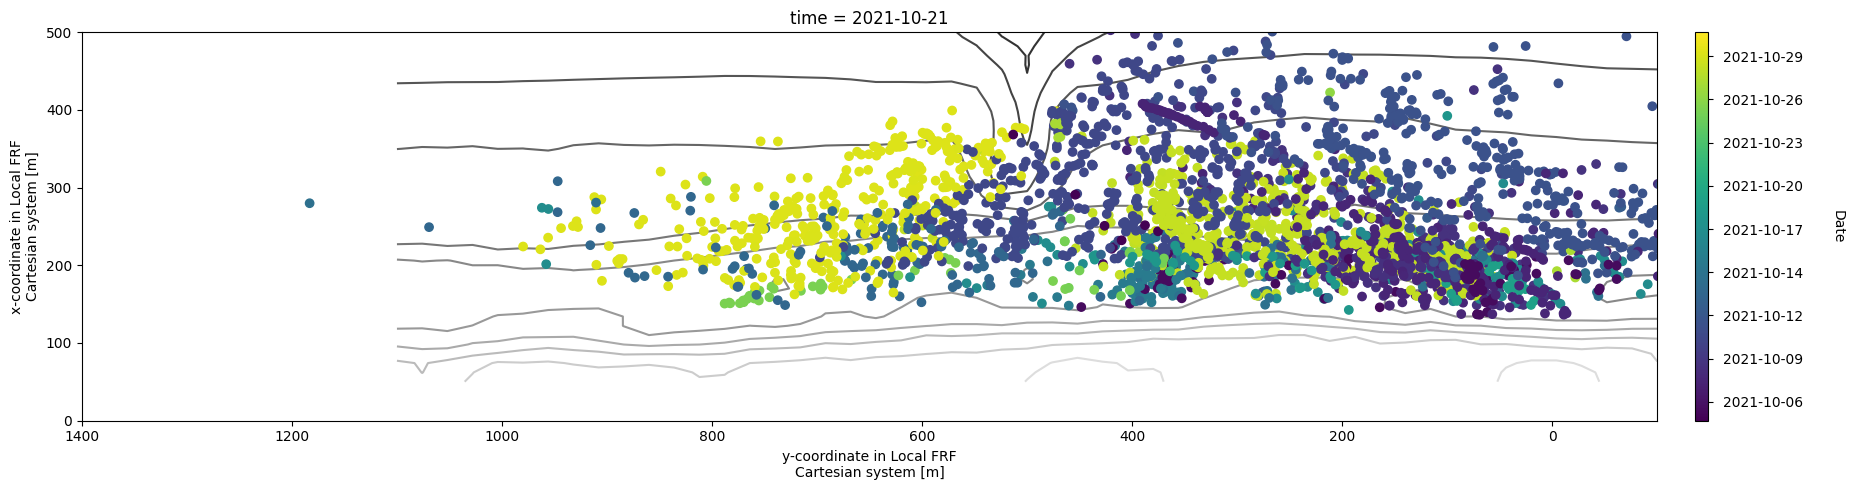

In [152]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import pandas as pd
import numpy as np

# Convert timestamps to seconds since epoch
def to_seconds(x):
    return (x - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')

# Custom formatter for colorbar ticks
def format_date(x, pos=None):
    return pd.Timestamp(x * 1e9).strftime('%Y-%m-%d')

plt.figure(figsize=(20, 5))
tmin = to_seconds(np.datetime64('2021-10-05'))
tmax = to_seconds(np.datetime64('2021-10-31'))

fig, ax = plt.subplots(figsize=(20, 5))

# Convert 'time' column to seconds since epoch
breaker_df['time_seconds'] = to_seconds(pd.to_datetime(breaker_df['time']))

scatter = ax.scatter(breaker_df['along shore location [m]'], 
                     breaker_df['cross shore location [m]'], 
                     c=breaker_df['time_seconds'], 
                     vmin=tmin, 
                     vmax=tmax,
                     cmap='viridis')

ax.set_title('All SWIFT Breakers')

# Create colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', aspect=30, pad=0.02)

# Set custom formatter for colorbar ticks
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_date))

# Adjust colorbar tick parameters
cbar.ax.yaxis.set_tick_params(pad=5)  # Moves labels away from colorbar

# Rotate the tick labels and adjust their position
for label in cbar.ax.get_yticklabels():
    label.set_ha('left')  # Horizontal alignment to left
    label.set_position((1.2, 0))  # Adjust x-position (1.2 moves it to the right)

# Label the colorbar
cbar.set_label('Date', rotation=270, labelpad=30)

bathy.elevation.T.plot.contour(cmap='gray', levels=np.linspace(-10, 5, 16), ax=ax, zorder=-1)
ax.set_ylim(0, 500)
ax.set_xlim(1400, -100)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'All SWIFT Breakers')

<Figure size 2000x500 with 0 Axes>

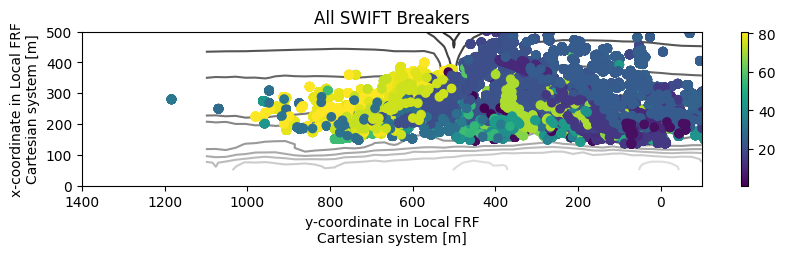

In [151]:
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

mission_breakers = breaker_df[breaker_df['mission number'] == 32]

plt.figure(figsize=(20, 5))
tmin = pd.to_datetime('20211005').timestamp()
tmax = pd.to_datetime('20211031').timestamp()


fig, ax = plt.subplots(figsize=(10, 2))

for mission in missions_with_video_data:
    # mission_breakers = breaker_df[breaker_df['mission number'] == mission]
    st = ax.scatter(breaker_df['along shore location [m]'], breaker_df['cross shore location [m]'], 
                c=breaker_df['mission number'])

bathy.elevation.T.plot.contour(cmap='gray', levels=np.linspace(-10, 5, 16), ax=ax, zorder=-1)
ax.set_ylim(0, 500)
ax.set_xlim(1400, -100)
plt.colorbar(st)
plt.title('All SWIFT Breakers')

Text(0.5, 1.0, 'All SWIFT Waves')

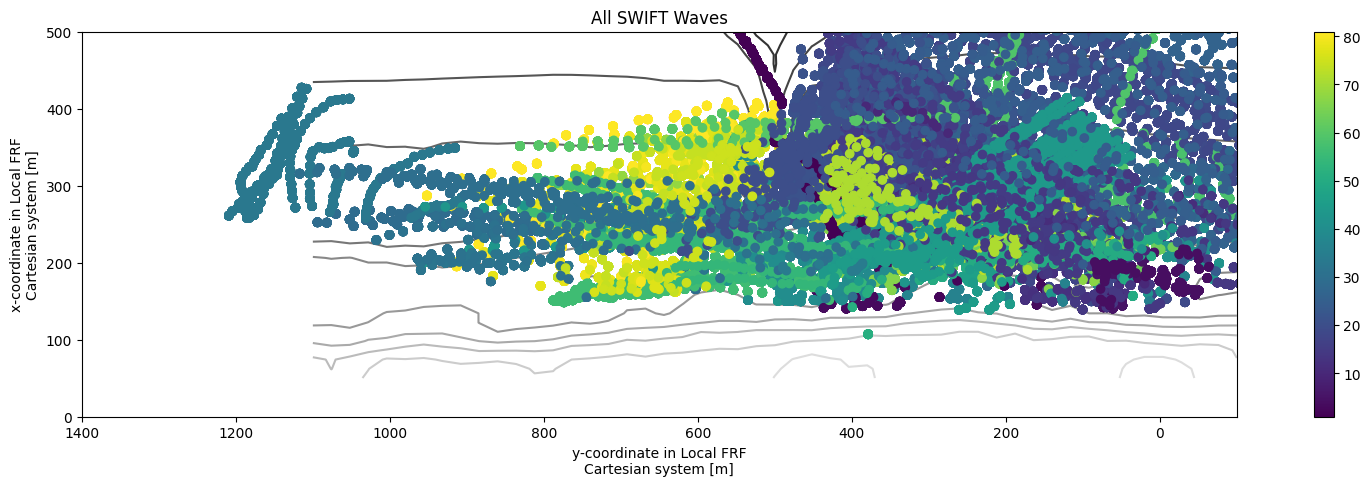

In [153]:
plt.figure(figsize=(20, 5))
stride = 10
for mission in missions_with_video_data:
    # mission_breakers = breaker_df[breaker_df['mission number'] == mission]
    plt.scatter(wave_df['along shore location [m]'][::stride], wave_df['cross shore location [m]'][::stride], c=wave_df['mission number'][::stride])

plt.gca().set_aspect(1)
plt.colorbar()
bathy.elevation.T.plot.contour(cmap='gray', levels=np.linspace(-10, 5, 16), zorder=-1)
plt.ylim(0, 500)
plt.xlim(1400, -100)
plt.title('All SWIFT Waves')

Text(0.5, 1.0, 'All SWIFT Waves & Breakers with with Good Video Data')

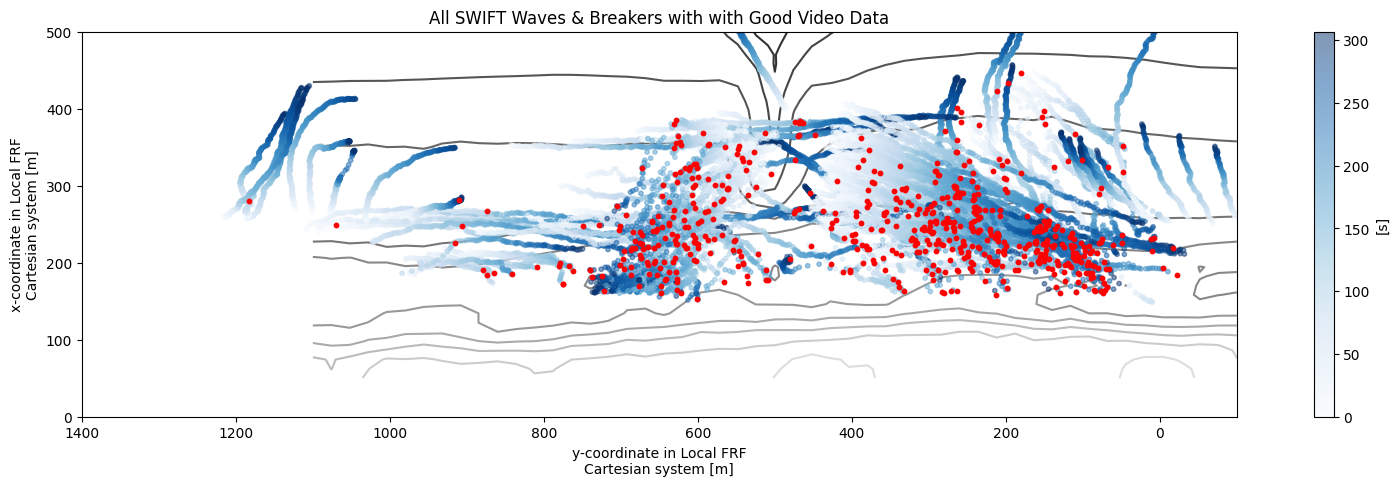

In [154]:
plt.figure(figsize=(20, 5))
stride = 1
for mission in missions_with_video_data:
    mission_breakers = breaker_df[breaker_df['mission number'] == mission]
    mission_waves = wave_df[wave_df['mission number'] == mission]
    time = pd.to_datetime(mission_waves['time'])
    time -= time.min()
    st = plt.scatter(mission_waves['along shore location [m]'][::stride], mission_waves['cross shore location [m]'][::stride], c=time.dt.total_seconds(), cmap='Blues', alpha=0.5, s=10)
    plt.scatter(mission_breakers['along shore location [m]'][::stride], mission_breakers['cross shore location [m]'][::stride], c='r', zorder=2, s=10)


bathy.elevation.T.plot.contour(cmap='gray', levels=np.linspace(-10, 5, 16), zorder=-1)
plt.ylim(0, 500)
plt.xlim(1400, -100)
plt.gca().set_aspect(1)
plt.colorbar(st, label='[s]')
plt.title('All SWIFT Waves & Breakers with with Good Video Data')

Text(0.5, 1.0, 'SWIFTS 10/13-10/14 - Missions 41-51')

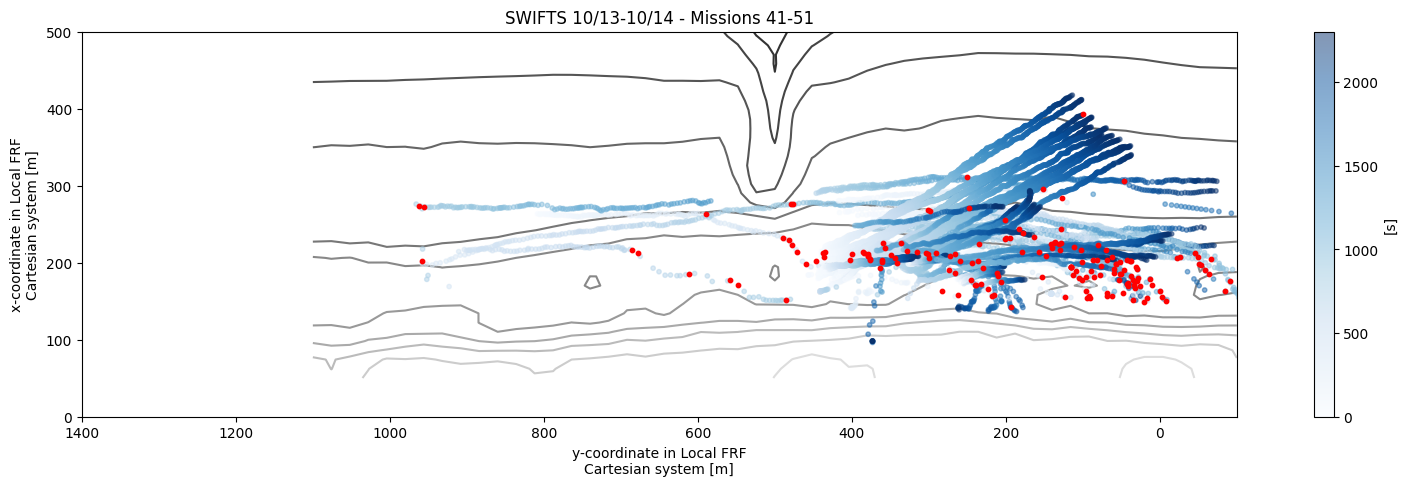

In [298]:
plt.figure(figsize=(20, 5))
stride = 1
for mission in np.arange(41, 52):
    mission_breakers = breaker_df[breaker_df['mission number'] == mission]
    mission_waves = wave_df[wave_df['mission number'] == mission]
    time = pd.to_datetime(mission_waves['time'])
    time -= time.min()
    st = plt.scatter(mission_waves['along shore location [m]'][::stride], mission_waves['cross shore location [m]'][::stride], c=time.dt.total_seconds(), cmap='Blues', alpha=0.5, s=10)
    plt.scatter(mission_breakers['along shore location [m]'][::stride], mission_breakers['cross shore location [m]'][::stride], c='r', zorder=2, s=10)


bathy.elevation.T.plot.contour(cmap='gray', levels=np.linspace(-10, 5, 16), zorder=-1)
plt.ylim(0, 500)
plt.xlim(1400, -100)
plt.gca().set_aspect(1)
plt.colorbar(st, label='[s]')
plt.title('SWIFTS 10/13-10/14 - Missions 41-51')


In [252]:
breaker_df['mission number'] == mission

ValueError: ('Lengths must match to compare', (3419,), (18,))

/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/xarray/plot/dataarray_plot.py:2001: UserWarning: The following kwargs were not used by contour: 'color'
  primitive = ax.contour(x, y, z, **kwargs)


Text(0.5, 1.0, 'SWIFTS 10/26-10/29 - Missions 55-81')

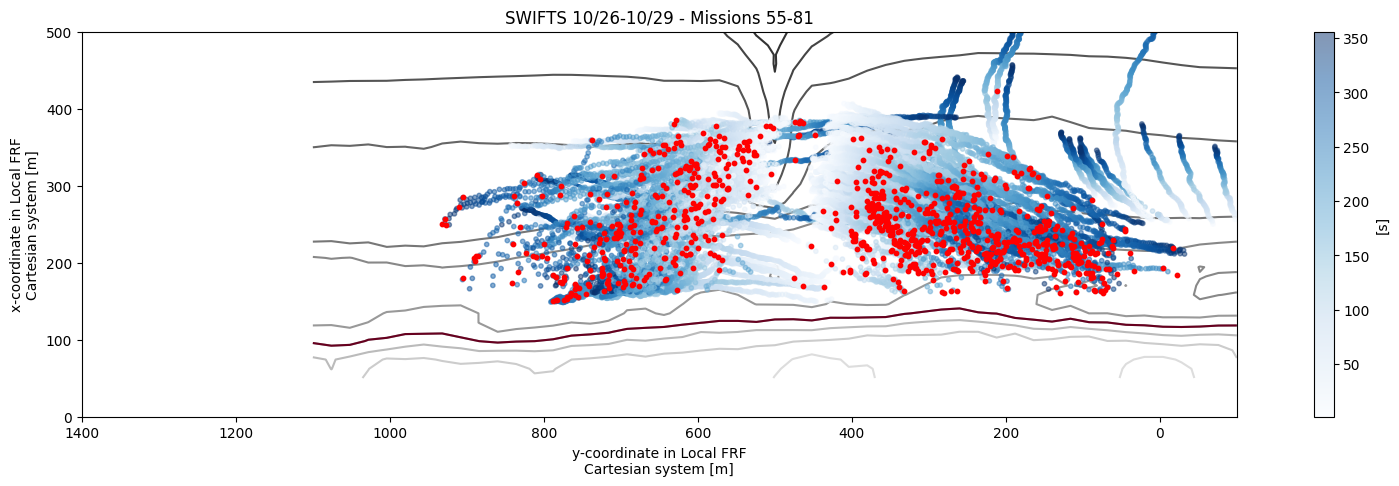

In [274]:
plt.figure(figsize=(20, 5))
stride = 1
for mission in np.arange(55, 81):
    mission_breakers = breaker_df[breaker_df['mission number'] == mission]
    mission_waves = wave_df[wave_df['mission number'] == mission]
    time = pd.to_datetime(mission_waves['time'])
    time -= time.min()
    st = plt.scatter(mission_waves['along shore location [m]'][::stride], mission_waves['cross shore location [m]'][::stride], c=time.dt.total_seconds(), cmap='Blues', alpha=0.5, s=10)
    plt.scatter(mission_breakers['along shore location [m]'][::stride], mission_breakers['cross shore location [m]'][::stride], c='r', zorder=2, s=10)


bathy.elevation.T.plot.contour(cmap='gray', levels=np.linspace(-10, 5, 16), zorder=-1)
bathy.elevation.T.plot.contour(color='k', levels=[0], zorder=-1)
plt.ylim(0, 500)
plt.xlim(1400, -100)
plt.gca().set_aspect(1)
plt.colorbar(st, label='[s]')
plt.title('SWIFTS 10/26-10/29 - Missions 55-81')


1
2
3
4
5
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
48
50
51
54
56
58
59
60
63
66
67
68
69
71
72
73
74
75
76
77
78
79
80
81


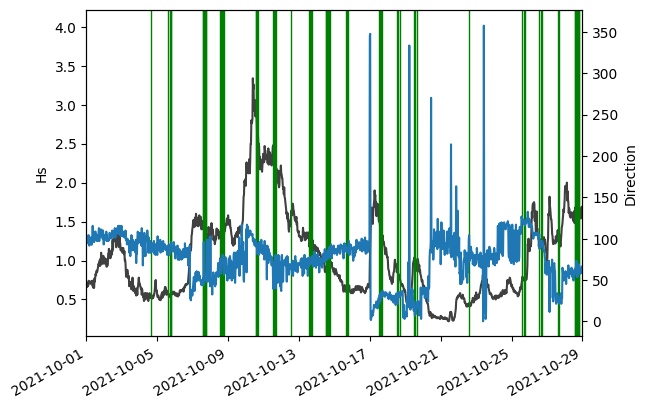

In [269]:
import json
starts = []
ends = []

ds = xr.load_dataset('/Users/mleclair/phd/code/dunex/data/cdip/433p1_2021.nc')


between_mission_interval = []
ids = []
for mission, times in sorted(json.load(open('../data/swift/time_extents.json')).items(), key = lambda fname: int(fname[0].split('_')[-1].split('.')[0])):
    id = int(mission.split('_')[-1].split('.')[0])
    # if id in missions_with_video_data:
    ids.append(id)
    print(id)
    starts.append(pd.to_datetime(times['min']))
    ends.append(pd.to_datetime(times['max']))

    if len(starts) > 1:
        between_mission_interval.append( starts[-1] - ends[-2])

fig = plt.figure()
for start, end in zip(starts, ends):
    span = plt.axvspan(
    start, end, color='g')


# plt.bar(starts, np.ones_like(starts), color='g', width=0.05)
# plt.bar(ends, np.ones_like(ends), color='r', width=0.05)
plt.plot(ds.time, ds.waveHs, c='k', alpha=0.75, zorder=-1)
plt.ylabel('Hs')
plt.twinx().plot(ds.time, ds.waveDp)
plt.ylabel('Direction')
plt.xlim(pd.to_datetime('20211001'), pd.to_datetime('20211029'))
fig.autofmt_xdate()

[]

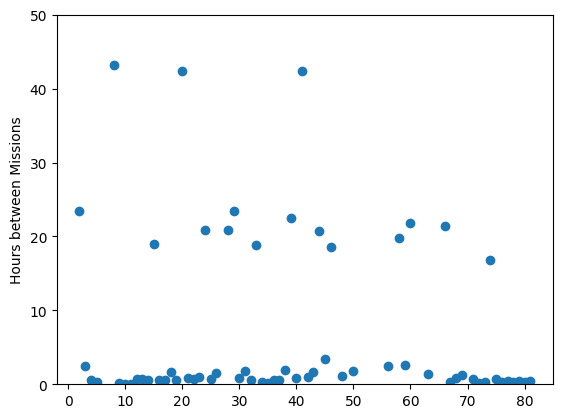

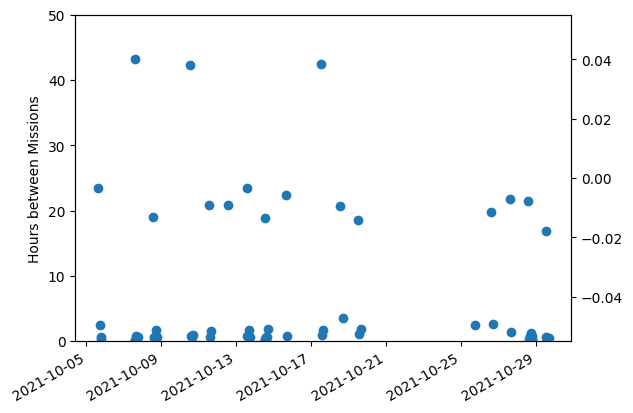

In [265]:
plt.scatter(ids[1:], pd.Series(between_mission_interval).dt.total_seconds() / 60 / 60 ) 
plt.ylim(0, 50)
plt.ylabel('Hours between Missions')
fig = plt.figure()
plt.scatter(starts[1:], pd.Series(between_mission_interval).dt.total_seconds() / 60 / 60 ) 
plt.ylim(0, 50)
plt.ylabel('Hours between Missions')
fig.autofmt_xdate()
plt.plot()
plt.twinx().plot()

In [278]:
print('id, start, end, interval')
for id, start, end, interval in zip(ids[1:], starts, ends, between_mission_interval):
    print(f'{id:02d}, {start}, {end}, {interval}')

id, start, end, interval
02, 2021-10-04 15:00:00, 2021-10-04 15:16:59, 0 days 23:25:01
03, 2021-10-05 14:42:00, 2021-10-05 14:49:59, 0 days 02:27:01
04, 2021-10-05 17:17:00, 2021-10-05 17:36:59, 0 days 00:36:01
05, 2021-10-05 18:13:00, 2021-10-05 18:23:59, 0 days 00:16:01
08, 2021-10-05 18:40:00, 2021-10-05 18:49:59, 1 days 19:12:01
09, 2021-10-07 14:02:00, 2021-10-07 14:15:59, 0 days 00:14:01
10, 2021-10-07 14:30:00, 2021-10-07 14:39:59, 0 days 00:06:16
11, 2021-10-07 14:46:15, 2021-10-07 15:09:59, 0 days 00:02:01
12, 2021-10-07 15:12:00, 2021-10-07 15:20:59, 0 days 00:44:31
13, 2021-10-07 16:05:30, 2021-10-07 16:20:59, 0 days 00:41:46
14, 2021-10-07 17:02:45, 2021-10-07 17:22:59, 0 days 00:38:01
15, 2021-10-07 18:01:00, 2021-10-07 18:15:29, 0 days 19:01:31
16, 2021-10-08 13:17:00, 2021-10-08 13:37:59, 0 days 00:32:31
17, 2021-10-08 14:10:30, 2021-10-08 14:31:59, 0 days 00:36:31
18, 2021-10-08 15:08:30, 2021-10-08 15:24:59, 0 days 01:39:31
19, 2021-10-08 17:04:30, 2021-10-08 17:41:59,

In [304]:
tmin = pd.Timestamp('20240101')
tmax = pd.Timestamp('20200101')
duration = pd.Timedelta(0)
for mission, times in sorted(json.load(open('../data/swift/time_extents.json')).items(), key = lambda fname: int(fname[0].split('_')[-1].split('.')[0])):
    id = int(mission.split('_')[-1].split('.')[0])
    
    
    # if id in np.arange(21, 36):
    # if id in np.arange(41, 51):
    if id in np.arange(56, 82):
        tmin = min(tmin, pd.to_datetime(times['min']))
        tmax = max(pd.to_datetime(times['max']), tmax)
        duration += pd.to_datetime(times['max']) - pd.to_datetime(times['min'])
print('Data', duration)
print(tmin)
print(tmax)
print('Period', tmax-tmin)
    

Data 0 days 04:30:50
2021-10-25 17:17:00
2021-10-29 16:16:29
Period 3 days 22:59:29


In [230]:
ds = xr.load_dataset('../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_29.nc')

In [301]:
mission_df = pd.read_csv('../drifters/thirdparty/DUNEXMainExp//microSWIFT_data/mission_df.csv')
mission_df[(mission_df['mission number'] > 41) & (mission_df['mission number'] < 51 )]

,Unnamed: 0,time,mission number,Hs [m],Tm [s],Mean Dir [deg],cross shore gamma location [m],break depth,freq [hz],energy density [m^2\hz],direction bins [deg],directional energy density [m^2/hz/deg],wind speed [m/s],wind direction [deg],water level [m]
5,5,2021-10-19 13:22:59.998800,48,0.734815,4.992037,32.649494,221.774888,2.099471,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.0018490841764033567, 0.0027538706410064257,...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[6.828362529631704e-06, 7.0564879024459515e-0...",5.009143,311.98163,0.476
20,20,2021-10-19 12:10:29.999400,46,0.759240,5.066045,30.049505,224.680146,2.169257,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.00203319375978431, 0.0030141629423124307, 0...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[1.0116618796018884e-05, 9.61883688432863e-06...",4.973834,303.20538,0.647
23,23,2021-10-17 13:29:29.997240,42,1.257376,5.384800,37.989323,298.612215,3.592503,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.007464770703543938, 0.0058866409091866065, ...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[3.5950135497841984e-05, 3.559683682397008e-0...",11.615914,332.97210,0.242
28,28,2021-10-17 15:55:59.991840,43,1.106649,5.459613,39.580516,265.446199,3.161855,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.006865168290019802, 0.005654938491564554, 0...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[2.5295939849456772e-05, 2.3967306333361194e-...",7.212333,326.09110,-0.234
47,47,2021-10-19 15:25:29.997480,50,0.681425,4.928942,37.939833,214.976299,1.946930,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.0021072676440533266, 0.00306303079822941, 0...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[5.946443707216531e-06, 6.397257948265178e-06...",5.644166,324.62140,-0.100
50,50,2021-10-18 13:30:29.995320,44,0.636598,5.163341,31.597371,208.716382,1.818850,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.001575206552832738, 0.0021132395041547113, ...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[4.434044967638329e-06, 4.30891714131576e-06,...",5.924667,292.11970,0.235
57,57,2021-10-18 17:25:59.998320,45,0.515203,5.330503,38.732592,180.013541,1.472008,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.0013039705940824206, 0.0021006600411041265,...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[5.080708888272056e-06, 4.96244592795847e-06,...",6.821500,269.92685,-0.458
